# Expérimentations — MLP (Nina)

Ce notebook met en évidence, **par des courbes**, les phénomènes du cours
(comme l'exige l'énoncé) sur mon MLP :

1. **Sous / sur-apprentissage** (impact du nombre de neurones)
2. **Vitesse de convergence** (impact du learning rate)
3. **Courbe d'apprentissage** (précision au fil des itérations)
4. **Comparaison des activations** (tanh / sigmoid / relu)
5. **Biais du dataset** (sur les vraies images)

> Chaque expérience est suivie d'une **analyse** — c'est ça que le jury valorise.


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "..", "python"))
import numpy as np
import matplotlib.pyplot as plt
from bindings import MLP
np.random.seed(0)

def accuracy(m, X, Y, n_out=1):
    bons = 0
    for x, y in zip(X, Y):
        p = m.predict(x); y = np.atleast_1d(y)
        ok = (np.argmax(p) == np.argmax(y)) if n_out > 1 else ((p[0] >= 0) == (y[0] >= 0))
        bons += int(ok)
    return 100.0 * bons / len(X)


## 1. Sous-apprentissage vs sur-apprentissage (nombre de neurones)

On prend deux nuages de points qui **se chevauchent** (données bruitées, non
parfaitement séparables), avec **peu** de données d'entraînement. On fait varier
le **nombre de neurones cachés** et on mesure la précision sur l'entraînement ET
sur le test.

h= 1 neurones : train=85%  test=86%
h= 2 neurones : train=87%  test=86%
h= 3 neurones : train=93%  test=80%
h= 5 neurones : train=97%  test=79%
h=10 neurones : train=93%  test=80%
h=20 neurones : train=95%  test=84%
h=40 neurones : train=92%  test=85%


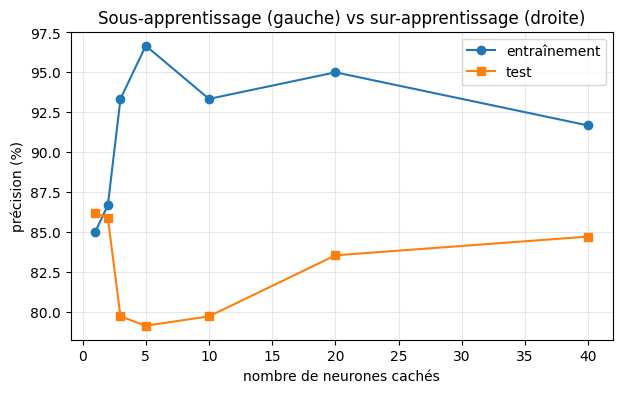

In [2]:
# Donnees bruitees (2 nuages qui se chevauchent)
N = 200
c0 = np.random.randn(N, 2) * 0.75 + np.array([0.0, 0.0])   # classe -1
c1 = np.random.randn(N, 2) * 0.75 + np.array([1.3, 1.3])   # classe +1
X = np.vstack([c0, c1]); Y = np.array([[-1.0]]*N + [[1.0]]*N)
idx = np.random.permutation(len(X)); X, Y = X[idx], Y[idx]
# peu de train (60), beaucoup de test (340) -> favorise le sur-apprentissage
Xtr, Ytr, Xte, Yte = X[:60], Y[:60], X[60:], Y[60:]

neurones = [1, 2, 3, 5, 10, 20, 40]
acc_tr, acc_te = [], []
for h in neurones:
    m = MLP([2, h, 1]); m.fit(Xtr, Ytr, steps=40_000, lr=0.05)
    acc_tr.append(accuracy(m, Xtr, Ytr)); acc_te.append(accuracy(m, Xte, Yte))
    print(f"h={h:2d} neurones : train={acc_tr[-1]:.0f}%  test={acc_te[-1]:.0f}%")

plt.figure(figsize=(7, 4))
plt.plot(neurones, acc_tr, "o-", label="entraînement")
plt.plot(neurones, acc_te, "s-", label="test")
plt.xlabel("nombre de neurones cachés"); plt.ylabel("précision (%)")
plt.title("Sous-apprentissage (gauche) vs sur-apprentissage (droite)")
plt.legend(); plt.grid(alpha=.3); plt.show()


**Analyse (à adapter avec tes chiffres) :**
- **Peu de neurones** (gauche) : train ET test bas → le modèle est **trop simple**, il **sous-apprend**.
- **Beaucoup de neurones** (droite) : le train monte vers 100% mais le test **stagne ou baisse** → le modèle **mémorise le bruit** du train, il **sur-apprend**.
- Le **bon compromis** est au milieu (assez complexe pour apprendre, assez simple pour généraliser).

## 2. Vitesse de convergence (learning rate)

Même cas (Cross), même nombre d'itérations, on fait varier **uniquement** le
learning rate.

lr=0.001  : 83%
lr=0.005  : 78%
lr=0.01   : 99%
lr=0.05   : 98%
lr=0.1    : 81%
lr=0.5    : 83%


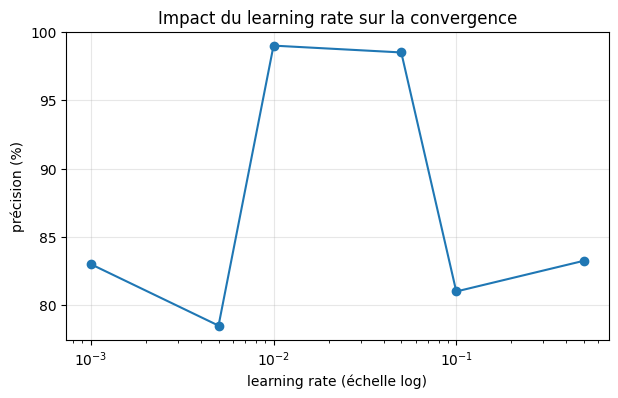

In [3]:
X = np.random.random((400, 2)) * 2 - 1
Y = np.array([[1.0] if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else [-1.0] for p in X])
lrs = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5]
accs = []
for lr in lrs:
    m = MLP([2, 4, 1]); m.fit(X, Y, steps=100_000, lr=lr)
    accs.append(accuracy(m, X, Y)); print(f"lr={lr:<6} : {accs[-1]:.0f}%")

plt.figure(figsize=(7, 4))
plt.plot(lrs, accs, "o-")
plt.xscale("log"); plt.xlabel("learning rate (échelle log)"); plt.ylabel("précision (%)")
plt.title("Impact du learning rate sur la convergence"); plt.grid(alpha=.3); plt.show()


**Analyse :**
- **lr trop petit** : le modèle apprend **trop lentement** → pas encore convergé après 100k itérations.
- **lr correct** (zone du milieu) : précision maximale.
- **lr trop grand** : l'apprentissage **saute** le minimum → instable, la précision **chute**.

## 3. Courbe d'apprentissage (précision au fil des itérations)

On entraîne le MLP **par paliers** et on mesure la précision à chaque palier.

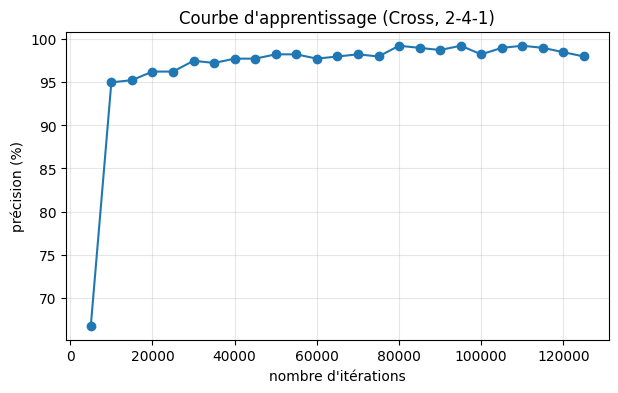

précision finale : 98.0 %


In [4]:
# Cross : convergence progressive -> on voit bien la MONTEE de la courbe
X = np.random.random((400, 2)) * 2 - 1
Y = np.array([[1.0] if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else [-1.0] for p in X])
m = MLP([2, 4, 1])
paliers, courbe = [], []
total = 0
for _ in range(25):
    m.fit(X, Y, steps=5_000, lr=0.03)    # paliers de 5k iterations
    total += 5_000
    paliers.append(total); courbe.append(accuracy(m, X, Y))

plt.figure(figsize=(7, 4))
plt.plot(paliers, courbe, "o-")
plt.xlabel("nombre d'itérations"); plt.ylabel("précision (%)")
plt.title("Courbe d'apprentissage (Cross, 2-4-1)"); plt.grid(alpha=.3); plt.show()
print("précision finale :", courbe[-1], "%")


**Analyse :**
- La précision **monte** avec les itérations, puis se **stabilise** (plateau) une fois le modèle convergé.
- C'est la « courbe d'apprentissage » : elle montre la **vitesse de convergence** du modèle.
- Au début la précision stagne (le réseau « cherche »), puis grimpe rapidement, puis plafonne.

## 4. Comparaison des fonctions d'activation

Même cas (Cross), même réglages, on change **uniquement** l'activation des couches cachées.

tanh     : 99%
sigmoid  : 74%
relu     : 71%


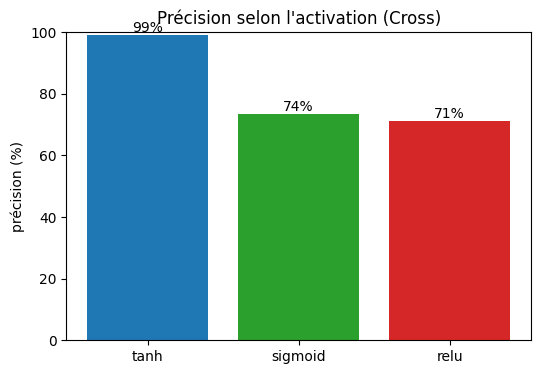

In [5]:
X = np.random.random((400, 2)) * 2 - 1
Y = np.array([[1.0] if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else [-1.0] for p in X])
noms = ["tanh", "sigmoid", "relu"]; res = []
for a in noms:
    m = MLP([2, 4, 1], activation=a); m.fit(X, Y, steps=150_000, lr=0.05)
    res.append(accuracy(m, X, Y)); print(f"{a:8s} : {res[-1]:.0f}%")

plt.figure(figsize=(6, 4))
plt.bar(noms, res, color=["#1f77b4", "#2ca02c", "#d62728"])
plt.ylabel("précision (%)"); plt.ylim(0, 100)
plt.title("Précision selon l'activation (Cross)")
for i, v in enumerate(res): plt.text(i, v + 1, f"{v:.0f}%", ha="center")
plt.show()


**Analyse :**
- **tanh** et **sigmoid** sont stables sur ce cas.
- **relu** peut être plus instable sur les petits réseaux (neurones « morts » : si l'entrée devient négative, le gradient est nul).
- Rappel : l'activation est un **paramètre** qu'on peut changer (`MLP([...], activation="relu")`).

## 5. Biais du dataset (sur les vraies images)

On entraîne sur les vraies images et on regarde la précision **par classe** sur
le test. Le dataset est **déséquilibré** (beaucoup de « aucun », peu d'« animal »).

répartition train : {'aucun': 184, 'humain': 65, 'animal': 31}
aucun    : 33%  (46 images)
humain   : 69%  (16 images)
animal   : 0%  (7 images)


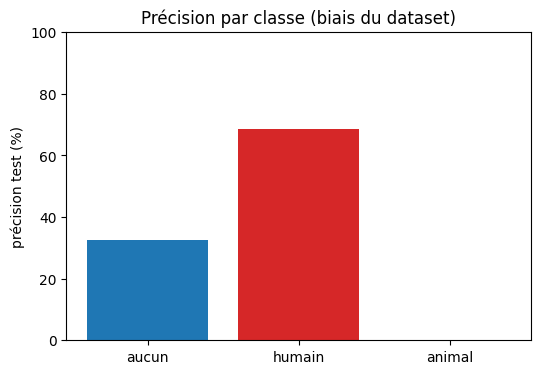

In [6]:
CLASSES = ["aucun", "humain", "animal"]
Xtr = np.load("../datasets/X_train.npy"); ytr = np.load("../datasets/y_train.npy")
Xte = np.load("../datasets/X_test.npy");  yte = np.load("../datasets/y_test.npy")
Ytr = -np.ones((len(ytr), 3)); Ytr[np.arange(len(ytr)), ytr] = 1.0

m = MLP([Xtr.shape[1], 32, 3]); m.fit(Xtr, Ytr, steps=20_000, lr=0.01)

# repartition du dataset
vals, cnt = np.unique(ytr, return_counts=True)
print("répartition train :", {CLASSES[v]: int(c_) for v, c_ in zip(vals, cnt)})

# precision par classe sur le test
par_classe = []
for e in range(3):
    idx = np.where(yte == e)[0]
    if len(idx) == 0: par_classe.append(0); continue
    bons = sum(np.argmax(m.predict(Xte[i])) == e for i in idx)
    par_classe.append(100 * bons / len(idx))
    print(f"{CLASSES[e]:8s} : {par_classe[-1]:.0f}%  ({len(idx)} images)")

plt.figure(figsize=(6, 4))
plt.bar(CLASSES, par_classe, color=["#1f77b4", "#d62728", "#2ca02c"])
plt.ylabel("précision test (%)"); plt.ylim(0, 100)
plt.title("Précision par classe (biais du dataset)")
plt.show()


**Analyse :**
- La classe **majoritaire** (« aucun ») est bien prédite, mais **humain / animal** sont mal classés
  → le modèle est **biaisé** vers la classe la plus fréquente (base d'exemples déséquilibrée).
- S'ajoute la **saturation de tanh** sur 12288 entrées (les neurones saturent → l'apprentissage est bloqué).
- **Pistes d'amélioration à discuter** : rééquilibrer le dataset, **initialisation de Xavier** (poids ÷ √(nb entrées)) pour éviter la saturation, réduire la taille des images.


## Conclusion

Ces expériences illustrent les phénomènes clés du ML :
**sous/sur-apprentissage**, **impact du learning rate**, **convergence**,
**effet de l'activation** et **biais du dataset**. L'essentiel n'est pas le code
mais l'**analyse** : savoir expliquer *pourquoi* on observe chaque courbe.
